# Import + GPU Setup + Mixed Precision

In [ ]:
# ============================================================
# PART 1 — IMPORT & GPU SETUP
# ============================================================

!pip install transformers
import tensorflow as tf
from tensorflow.keras import mixed_precision
import numpy as np
import pandas as pd
import gc

from transformers import TFDistilBertModel, DistilBertTokenizerFast
from tensorflow.keras.layers import Input, Bidirectional, GRU, GlobalMaxPooling1D, Dropout, Dense
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score, classification_report


# Enable mixed precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

# GPU memory growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print("Memory growth enabled on GPU")
    except:
        pass


Memory growth enabled on GPU


# Global Parameters

In [ ]:
MAX_LEN = 64       # Dikurangi dari 128 → hemat memori
BATCH_SIZE = 8     # Dikurangi dari 16 → aman untuk T4
EPOCHS = 1         # Sementara untuk Optuna testing



# Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = "/content/drive/MyDrive/DistilBERT-7-Mei/combined_dataset.csv"
df = pd.read_csv(file_path)

X = df["clean_text"].astype(str)
y = df["encoded_label"]

# Step 1: Test split 20%
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Step 2: Validation 10% dari total → 12.5% dari 80%
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, stratify=y_temp, random_state=42
)

print(len(X_train), len(X_val), len(X_test))


1445 207 414


# Load Tokenizer + Tokenize Function

In [ ]:
# ============================================================
# PART 4 — TOKENIZER
# ============================================================

tokenizer = DistilBertTokenizerFast.from_pretrained("cahya/distilbert-base-indonesian")

def tokenize(texts):
    return tokenizer(
        list(texts),
        max_length=MAX_LEN,
        truncation=True,
        padding="max_length",
        return_tensors="tf"
    )


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/62.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

# Tokenisasi data Split Train/Test/Val

In [ ]:
train_inputs = tokenize(X_train)
val_inputs   = tokenize(X_val)
test_inputs  = tokenize(X_test)

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


# Load Model Distilbert Indonesia Lang

In [ ]:
# ============================================================
# PART 6 — LOAD BERT MODEL ONCE (IMPORTANT)
# ============================================================

bert_model = TFDistilBertModel.from_pretrained("cahya/distilbert-base-indonesian", from_pt=True)
bert_model.trainable = False   # freeze → hemat memory

# Explicitly build the bert_model to define its input shape for Keras functional API
# (None, MAX_LEN) for input_ids and (None, MAX_LEN) for attention_mask
bert_model.build(input_shape=[(None, MAX_LEN), (None, MAX_LEN)])

pytorch_model.bin:   0%|          | 0.00/273M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_transform.weight', 'vocab_layer_norm.weight', 'vocab_projector.bias', 'vocab_projector.weight', 'vocab_transform.bias', 'vocab_layer_norm.bias']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the mode

# Build Model Function

In [ ]:
# ============================================================
# PART 7 — BUILD MODEL FUNCTION
# ============================================================

# Define a wrapper for the frozen bert_model
class BertWrapper(tf.keras.layers.Layer):
    def __init__(self, bert_model_instance, **kwargs):
        super().__init__(**kwargs)
        # Register the bert_model_instance as a sub-layer explicitly
        self.bert_model = bert_model_instance

    def call(self, inputs):
        input_ids, attention_mask = inputs
        # The transformers model expects keyword arguments
        return self.bert_model(input_ids=input_ids, attention_mask=attention_mask, return_dict=False)[0]

def build_model(gru_units, dropout_rate, lr):

    input_ids = Input(shape=(MAX_LEN,), dtype=tf.int32, name="input_ids")
    att_mask  = Input(shape=(MAX_LEN,), dtype=tf.int32, name="attention_mask")

    # Instantiate the wrapper with the global bert_model
    bert_wrapper = BertWrapper(bert_model, name="bert_wrapper_layer")
    hidden_states = bert_wrapper([input_ids, att_mask]) # Pass inputs as a list/tuple

    x = Bidirectional(GRU(gru_units, return_sequences=True))(hidden_states)
    x = GlobalMaxPooling1D()(x)
    x = Dropout(dropout_rate)(x)

    out = Dense(1, activation="sigmoid", dtype="float32")(x)

    model = Model(inputs=[input_ids, att_mask], outputs=out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Training Final Model

In [ ]:
# Best parameters: {'gru_units': 43, 'dropout': 0.3294464290655994, 'lr': 0.000356063920879353}

final_model = build_model(
    gru_units = 43,
    dropout_rate = 0.3294464290655994,
    lr = 0.000356063920879353
)

final_model.fit(
    dict(train_inputs),
    y_train,
    epochs=10,
    batch_size=BATCH_SIZE,
    validation_data=(dict(val_inputs), y_val.values) # Pass validation data explicitly as a dictionary
)
# === Evaluation on TEST set ===
from sklearn.metrics import f1_score, classification_report, confusion_matrix

y_pred = final_model.predict(dict(test_inputs)) # Use dict(test_inputs) instead of X_test_vec
y_pred = (y_pred > 0.5).astype(int).reshape(-1)

f1_macro = f1_score(y_test, y_pred, average="macro")
cls_report = classification_report(y_test, y_pred, output_dict=True)
cm = confusion_matrix(y_test, y_pred)

print("\n=== Final BiGRU Test Evaluation ===")
print("F1-macro:", f1_macro)
print("Accuracy:", cls_report["accuracy"])
print("Classification Report:", cls_report)
print("Confusion Matrix:\n", cm)

# === Inference Time Benchmark (selaras dengan BERT) ===
import time
benchmark_size = min(32, len(y_test)) # Use len(y_test) for size
subset = {'input_ids': test_inputs['input_ids'][:benchmark_size], 'attention_mask': test_inputs['attention_mask'][:benchmark_size]} # Correctly slice the dictionary of tensors

# Warm-up
for _ in range(3):
    _ = final_model.predict(subset, verbose=0)

# Benchmark
n_runs = 50
start = time.time()
for _ in range(n_runs):
    _ = final_model.predict(subset, verbose=0)
end = time.time()

avg_time = (end - start) / n_runs
samples_per_second = benchmark_size / avg_time

print("\n🕒 Avg batch inference time:", avg_time)
print("📊 Throughput:", samples_per_second, "samples/sec")

Epoch 1/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.6933 - loss: 0.5786 - val_accuracy: 0.8261 - val_loss: 0.3869
Epoch 2/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.8453 - loss: 0.3519 - val_accuracy: 0.8502 - val_loss: 0.3455
Epoch 3/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.9221 - loss: 0.2205 - val_accuracy: 0.8454 - val_loss: 0.3512
Epoch 4/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9409 - loss: 0.1922 - val_accuracy: 0.8937 - val_loss: 0.2945
Epoch 5/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.9564 - loss: 0.1484 - val_accuracy: 0.8889 - val_loss: 0.2891
Epoch 6/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.9581 - loss: 0.1280 - val_accuracy: 0.8696 - val_loss: 0.2939
Epoch 7/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.9642 - loss: 0.1106 - val_accuracy: 0.8937 - val_loss: 0.2810
Epoch 8/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.9880 - loss: 0.0656 - val_acc

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step
              precision    recall  f1-score   support

         0.0     0.9062    0.8904    0.8982       228
         1.0     0.8684    0.8871    0.8777       186

    accuracy                         0.8889       414
   macro avg     0.8873    0.8887    0.8879       414
weighted avg     0.8893    0.8889    0.8890       414



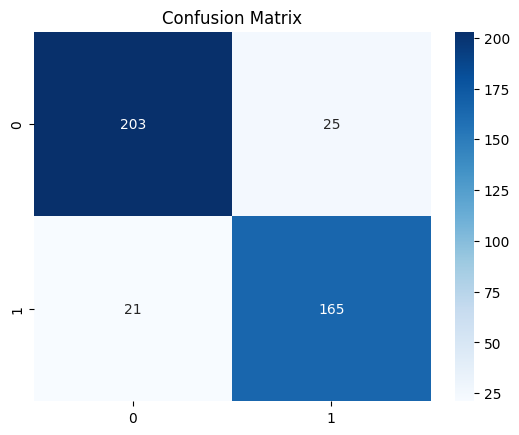

Macro F1: 0.8879448314818301


In [ ]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = (final_model.predict(dict(test_inputs)) > 0.5).astype("int32")

print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

print("Macro F1:", f1_score(y_test, y_pred, average="macro"))